# Analyse measurements taken on the lsm6ds3

Here we anaylse the data when the magic ward is in movement

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def readMeasurementFile(filename):
    file = open(filename,"r")
    all = file.read()
    cnt = []
    acc = []
    gyro = []
    lines = all.split("\n")
    # print(len(lines))
    for i in range(len(lines)-1):
        tmp1 = lines[i].split(":")
        cnt.append(int(tmp1[0]))
        tmp2 = tmp1[1].split("|")
        tmp3 = tmp2[0].split(",")
        tmp4 = tmp2[1].split(",")
        gyro.append([float(tmp3[0]),float(tmp3[1]),float(tmp3[2])])
        acc.append([float(tmp4[0]),float(tmp4[1]),float(tmp4[2])])
    return gyro,acc
    # print("cnt: ",cnt)
    # print("gyro: ",gyro)
    # print("acc: ",acc)
    

In [3]:
def readOrientationFile(filename):
    file = open(filename,"r")
    all = file.read()
    cnt = []
    orient = []
    lines = all.split("\n")
    # print(len(lines))
    for i in range(len(lines)-1):
        tmp1 = lines[i].split(":")
        cnt.append(int(tmp1[0]))
        tmp2 = tmp1[1].split(",")
        orient.append([float(tmp2[0]),float(tmp2[1]),float(tmp2[2])])
    return orient

In [4]:
def readGravityFile(filename):
    file = open(filename,"r")
    all = file.read()
    cnt = []
    gravity = []
    lines = all.split("\n")
    # print(len(lines))
    for i in range(len(lines)-1):
        tmp1 = lines[i].split(":")
        cnt.append(int(tmp1[0]))
        tmp2 = tmp1[1].split(",")
        gravity.append([float(tmp2[0]),float(tmp2[1]),float(tmp2[2])])
    return gravity

### Interpreting measured data for downward movement
Since there is no rotation the gyro values should be essentially zero.  
The gyroscope drift and gravity has been measure with static measurements (no movement) and the wand orientated vertically

The orientation of the lsm6ds3 in space is as follows:  
![orientation](images/lsm6ds3_orientation.png "lsm6ds3 orientation")  
* Moving right goes in negative x direction
* Moving forward moves in negative z direction
* Moving down moves in negative y direction

In [5]:
gyro_drift = [3.1957019230769257, -4.300221153846158, -1.9101826923076917]
gravity = [0.015230769230769218, -1.0048846153846152, 0.06285576923076924]

In [6]:
gyro_data, acc_data = readMeasurementFile("data/meas.dat")
orient_data = readOrientationFile("data/orient.dat")
gravity_data = readGravityFile("data/gravity.dat")

In [7]:
def plot_gyro(title):
    gyro_plt = (np.array(gyro_data)[:,0], 
                np.array(gyro_data)[:,1], 
                np.array(gyro_data)[:,2])
    for i in range(len(gyro_plt[0])):
        gyro_plt[0][i] -= gyro_drift[0]
        gyro_plt[1][i] -= gyro_drift[1]   
        gyro_plt[2][i] -= gyro_drift[2]
    plt.title(title)
    plt.plot(gyro_plt[0],label="gyro_x")
    plt.plot(gyro_plt[1],label="gyro_y")
    plt.plot(gyro_plt[2],label="gyro_z")
    plt.legend(loc="upper right")

In [8]:
def plot_acc(title):
    acc_plt = (np.array(acc_data)[:,0], 
                np.array(acc_data)[:,1], 
                np.array(acc_data)[:,2])

    plt.title(title)
    plt.plot(acc_plt[0],label="acc_x")
    plt.plot(acc_plt[1],label="acc_y")
    plt.plot(acc_plt[2],label="acc_z")
    plt.legend(loc="upper right")

In [9]:
def plot_gravity_corrected_acc(title):
    acc_plt_corr = [np.array(acc_data)[:,0], 
                    np.array(acc_data)[:,1], 
                    np.array(acc_data)[:,2]]

    acc_plt_corr[0] -= gravity[0]
    acc_plt_corr[1] -= gravity[1]
    acc_plt_corr[2] -= gravity[2]

    plt.title(title)
    plt.plot(acc_plt_corr[0],label="acc_x")
    plt.plot(acc_plt_corr[1],label="acc_y")
    plt.plot(acc_plt_corr[2],label="acc_z")
    plt.legend(loc="upper right")

In [10]:
acc_plt_corr = [np.array(acc_data)[:,0], 
                    np.array(acc_data)[:,1], 
                    np.array(acc_data)[:,2]]
print(type(acc_plt_corr))

<class 'list'>


In [11]:
def plot_velocity(title):
    friction_fudge = 0.98
    velocity = []
    velocity.append(acc_data[0])
    for i in range(len(acc_data)-1):
        tmp_velocity = [(velocity[i][0] + acc_data[i][0]) * friction_fudge,
                        (velocity[i][1] + acc_data[i][1]) * friction_fudge,
                        (velocity[i][2] + acc_data[i][2]) * friction_fudge] 
        velocity.append(tmp_velocity)
    vel_plt = (np.array(velocity)[:,0], 
                np.array(velocity)[:,1], 
                np.array(velocity)[:,2])
    print("Length of velocity array: ",len(velocity))
    plt.title(title)
    plt.plot(vel_plt[0],label="velocity_x")
    plt.plot(vel_plt[1],label="velocity_y")
    plt.plot(vel_plt[2],label="velocity_z")
    plt.legend(loc="upper right")

In [12]:
def plot_orient(title):
    orient_plt = (np.array(orient_data)[:,0], 
                  np.array(orient_data)[:,1], 
                  np.array(orient_data)[:,2])
    plt.title(title)
    plt.plot(orient_plt[0],label="orientation_x")
    plt.plot(orient_plt[1],label="orientation_y")
    plt.plot(orient_plt[2],label="orientation_z")
    plt.legend(loc="upper right")

In [13]:
def plot_gravity(title):
    gravity_plt = (np.array(gravity_data)[:,0], 
                  np.array(gravity_data)[:,1], 
                  np.array(gravity_data)[:,2])
    plt.title(title)
    plt.plot(gravity_plt[0],label="gravity_x")
    plt.plot(gravity_plt[1],label="gravity_y")
    plt.plot(gravity_plt[2],label="gravity_z")
    plt.legend(loc="upper right")

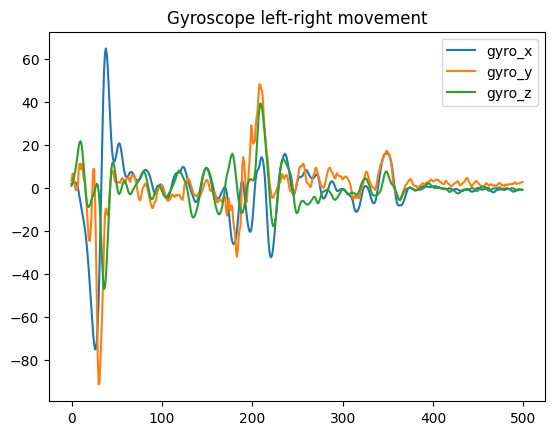

In [14]:
plot_gyro("Gyroscope left-right movement")

We see a strong rotation around the x axis which looks ok

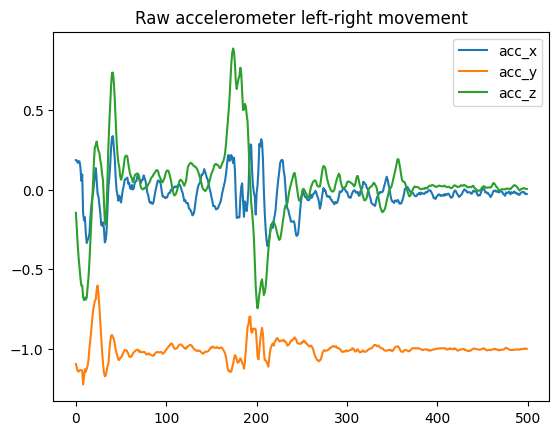

In [15]:
plot_acc("Raw accelerometer left-right movement")

In [16]:
print(acc_data[0])

[-0.257, -0.98, 0.111]


In [16]:
acc_plt = (np.array(acc_data)[:,0], 
            np.array(acc_data)[:,1], 
            np.array(acc_data)[:,2])
print(acc_plt[1][0])

-1.005


Subtract gravity from acc and plot again

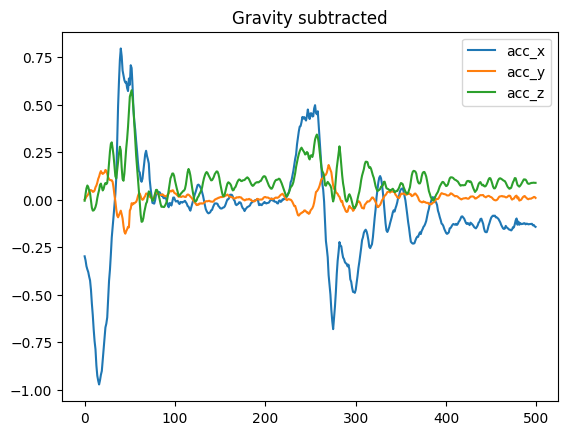

In [35]:
plot_gravity_corrected_acc("Gravity subtracted")

Length of velocity array:  500


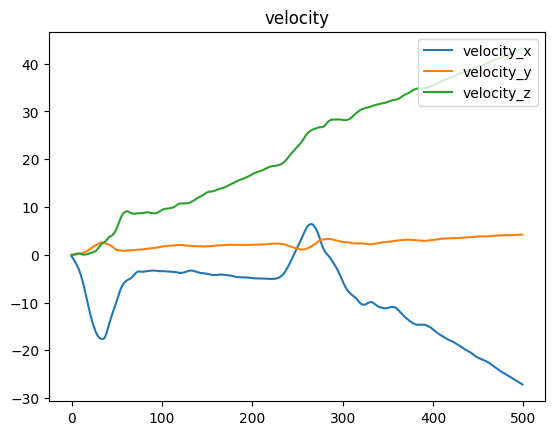

In [45]:
friction_fudge = 0.90
velocity = []
velocity.append([acc_data[0][0] - gravity[0], acc_data[0][1] - gravity[1],acc_data[0][2] - gravity[2]])
for i in range(len(acc_data)-1):
    tmp_velocity = [velocity[i][0] +  (acc_data[i][0] - gravity[0]) * friction_fudge,
                    velocity[i][1] +  (acc_data[i][1] - gravity[1]) * friction_fudge,
                    velocity[i][2] +  (acc_data[i][2] - gravity[2]) * friction_fudge] 
    velocity.append(tmp_velocity)
        
vel_plt = (np.array(velocity)[:,0], 
            np.array(velocity)[:,1], 
            np.array(velocity)[:,2])
print("Length of velocity array: ",len(velocity))
plt.title("velocity")
plt.plot(vel_plt[0],label="velocity_x")
plt.plot(vel_plt[1],label="velocity_y")
plt.plot(vel_plt[2],label="velocity_z")
plt.legend(loc="upper right")

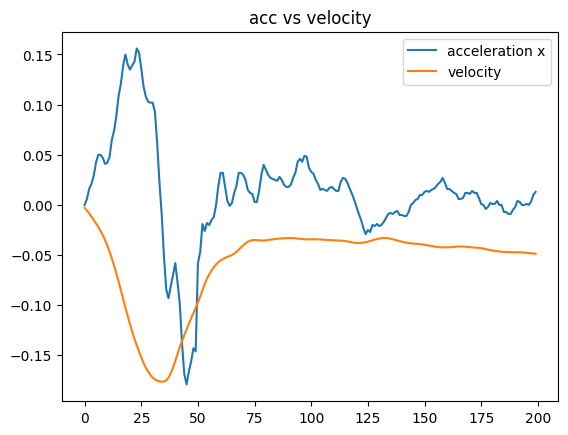

In [46]:
vel_plt = (np.array(velocity)[:,0], 
            np.array(velocity)[:,1], 
            np.array(velocity)[:,2])
acc_x_corr = []
for i in range(200):
    acc_x_corr.append(acc_data[i][1] -gravity[1])
    vel_plt[0][i] /= 100.0
plt.title("acc vs velocity")
plt.plot(acc_x_corr,label="acceleration x")
plt.plot(vel_plt[0][:200],label="velocity")
plt.legend(loc="upper right")

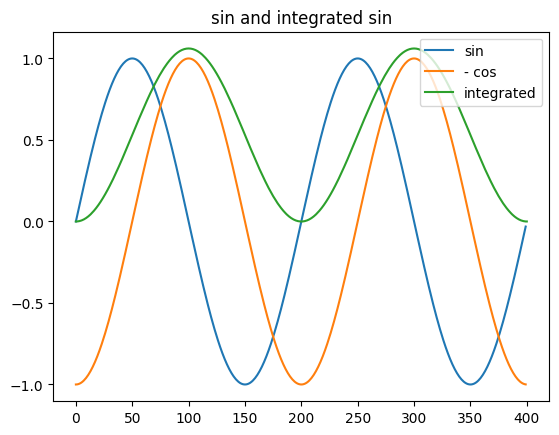

In [73]:
from math import sin,cos,pi
s = []
c = []
integ = []
integ.append(sin(0))

for i in range(400):
    s.append(sin(2*pi*i/200))

for i in range(400):
    c.append(-cos(2*pi*i/200))

for i in range(400):
    integ.append(integ[i-1] + s[i])
for i in range(400):
    integ[i] /=30
plt.title("sin and integrated sin")
plt.plot(s,label="sin")
plt.plot(c,label="- cos")
plt.plot(integ, label="integrated")
plt.legend(loc="upper right")